In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a dataset
# Let´s build the values lists
#value_n_list = [1, 2, 2, 2, 4, 4, 5, 6]
#print(value_n_list)

value_x_list = [1, 2, 2, 3, 4, 4, 5, 6] # valores de X
value_y_list = [2, 3, 4, 4, 4, 6, 5, 7] # valores de Y
# value_bmi_list will be calculated: bmi = w/(h^2)
#value_bmi_list = [25,25,25] # init values [kg/m2]

# Let´s use a dictionary ({key:value})
# with the format {"str":list}
data_dict = {"X":value_x_list,
             "Y":value_y_list}
             #"XY":value_x_list*value_y_list,
             #"XX":value_x_list*value_x_list}

print(data_dict)

# Turn a dictionary into a dataframe
df = pd.DataFrame(data_dict)

#print(df)
# Call a variable
df

{'X': [1, 2, 2, 3, 4, 4, 5, 6], 'Y': [2, 3, 4, 4, 4, 6, 5, 7]}


,X,Y
0,1,2
1,2,3
2,2,4
3,3,4
4,4,4
5,4,6
6,5,5
7,6,7


In [3]:
df['XY'] = df['X'] * (df['Y'])
df['XX'] = df['X'] ** 2
df

,X,Y,XY,XX
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,6,24,16
6,5,5,25,25
7,6,7,42,36


In [4]:
#df.loc['Total'] = df.sum()
#display(df)

In [5]:
#sumas = df.iloc[:-1].sum()
sumas = df.sum()
print(sumas)

X      27
Y      35
XY    135
XX    111
dtype: int64


In [6]:
n=len(df)

sum_x = df["X"].sum()
sum_y = df["Y"].sum()
sum_xy = df["XY"].sum()
sum_xx = df["XX"].sum()

m=(n*sum_xy - sum_x*sum_y)/(n*sum_xx - sum_x**2)
print("pendiente",m)

pendiente 0.8490566037735849


In [7]:
B=(sum_y/len(df))-m*(sum_x/len(df))
print("intercepto", B)

intercepto 1.5094339622641506


In [8]:
df['Ypred'] = m*df['X'] + B
df['Y-Ypred'] = df['Y'] - df['Ypred']
df['error'] = df['Y-Ypred']**2
df

,X,Y,XY,XX,Ypred,Y-Ypred,error
0,1,2,2,1,2.358491,-0.358491,0.128515
1,2,3,6,4,3.207547,-0.207547,0.043076
2,2,4,8,4,3.207547,0.792453,0.627981
3,3,4,12,9,4.056604,-0.056604,0.003204
4,4,4,16,16,4.905660,-0.905660,0.820221
5,4,6,24,16,4.905660,1.094340,1.197579
6,5,5,25,25,5.754717,-0.754717,0.569598
7,6,7,42,36,6.603774,0.396226,0.156995


In [9]:
TotalError = df['error'].sum()
print(TotalError)

3.5471698113207544


In [10]:
PromedioError = df['error'].mean()
print(PromedioError)

0.4433962264150943


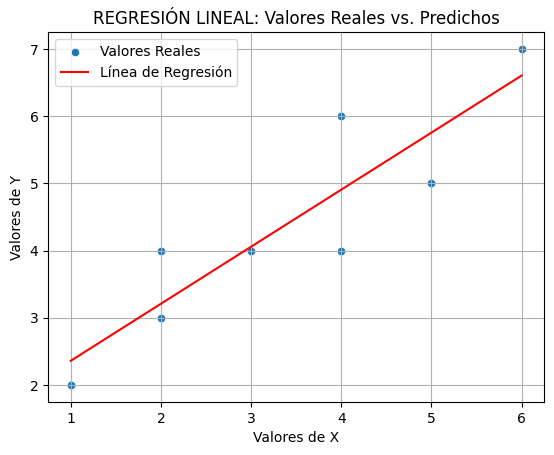

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='X', y='Y', label='Valores Reales')
sns.lineplot(data=df, x='X', y='Ypred', label='Línea de Regresión', color='red')
plt.title('REGRESIÓN LINEAL: Valores Reales vs. Predichos')
plt.xlabel('Valores de X')
plt.ylabel('Valores de Y')
plt.legend()
plt.grid(True)
plt.show()